<a href="https://colab.research.google.com/github/natic23/BIDS11-AssignmentData/blob/main/BIDS_assignment_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://github.com/ICL-BMB-BiDS/BIDS11-AssignmentData/raw/refs/heads/main/BIDS_assignment_training_data_unlabelled.xlsx
!wget https://github.com/natic23/BIDS11-AssignmentData/raw/refs/heads/main/BIDS_assignment_training_data.xlsx
!wget https://github.com/natic23/BIDS11-AssignmentData/raw/refs/heads/main/BIDS_assignment_test_data.xlsx

--2026-05-20 10:10:14--  https://github.com/ICL-BMB-BiDS/BIDS11-AssignmentData/raw/refs/heads/main/BIDS_assignment_training_data_unlabelled.xlsx
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ICL-BMB-BiDS/BIDS11-AssignmentData/refs/heads/main/BIDS_assignment_training_data_unlabelled.xlsx [following]
--2026-05-20 10:10:14--  https://raw.githubusercontent.com/ICL-BMB-BiDS/BIDS11-AssignmentData/refs/heads/main/BIDS_assignment_training_data_unlabelled.xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3637608 (3.5M) [application/octet-stream]
Saving to: ‘BIDS_assignment_training_data_unlabelled.x

In [2]:
import pandas as pd
import numpy as np ### for working with numpy arrays

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn import metrics
from sklearn.metrics import silhouette_score, silhouette_samples

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import colorConverter

In [ ]:
df_unlabelled = pd.read_excel("/content/BIDS_assignment_training_data_unlabelled.xlsx")
X_test=pd.read_excel("/content/BIDS_assignment_test_data.xlsx")
X_train = pd.read_excel("/content/BIDS_assignment_training_data.xlsx")


In [ ]:
df_unlabelled.head()

,ID,Sex,Ethnicity,Smoking,Acetic acid,2-Ethoxy-3-methylpyrazine,Propionic acid,Glycine,4-Hydroxy-2-butenoic acid gamma-lactone,gamma-Butyrolactone,...,CMP,"Adenosine 2,3-cyclic phosphate",3-AMP,4-Methylgallic acid 3-glucuronide,GMP,Xanthylic acid,Epicatechin 3-O-(3-O-methylgallate),"(2S)-2-[[(2R,3S,4R,5R)-5-(6-Aminopurin-9-yl)-3,4-dihydroxyoxolan-2-yl]methylamino]-4-sulfanylbutanoic acid",trans-Piceid,GDP
0,EM_0008,1,1,1,144.788687,61.935607,325.100053,405.246961,468.268910,18408.460360,...,69.178093,934.258972,20121.64988,1209.155537,733.834368,137.533757,660.760405,1268.035368,615.734428,253.710128
1,EM_0010,1,1,2,2636.545490,213.792540,1110.774424,1267.409321,157.812235,53009.062540,...,12.687008,1137.733854,38810.15091,532.141154,419.383545,62.586923,211.036231,1250.609986,1928.658497,35.707499
2,EM_0011,0,0,0,112.383812,59.494967,109.029632,274.993686,205.521432,9317.956772,...,56.974417,699.342356,26885.97046,842.068174,1282.929249,785.891588,1308.155640,732.249068,5568.902651,71.629996
3,EM_0012,0,0,0,113.095045,172.124086,229.375722,230.679234,312.896894,21347.622270,...,154.415927,2117.382162,17384.77430,1082.506736,635.446618,13.264748,1910.551972,462.691219,419.724277,416.692075
4,EM_0013,1,1,1,64.080842,60.994862,83.675004,290.996197,122.845146,9269.345907,...,256.987415,1237.185536,41214.98702,762.484661,1081.950882,283.174544,138741.019100,1071.587463,108.963160,23.996545


### PCA

In [ ]:
scaler= StandardScaler()
pca_scaled= scaler.fit_transform(df_unlabelled.iloc[:,4:])
pca= PCA(n_components=5)
pca_df= pca.fit_transform(pca_scaled)


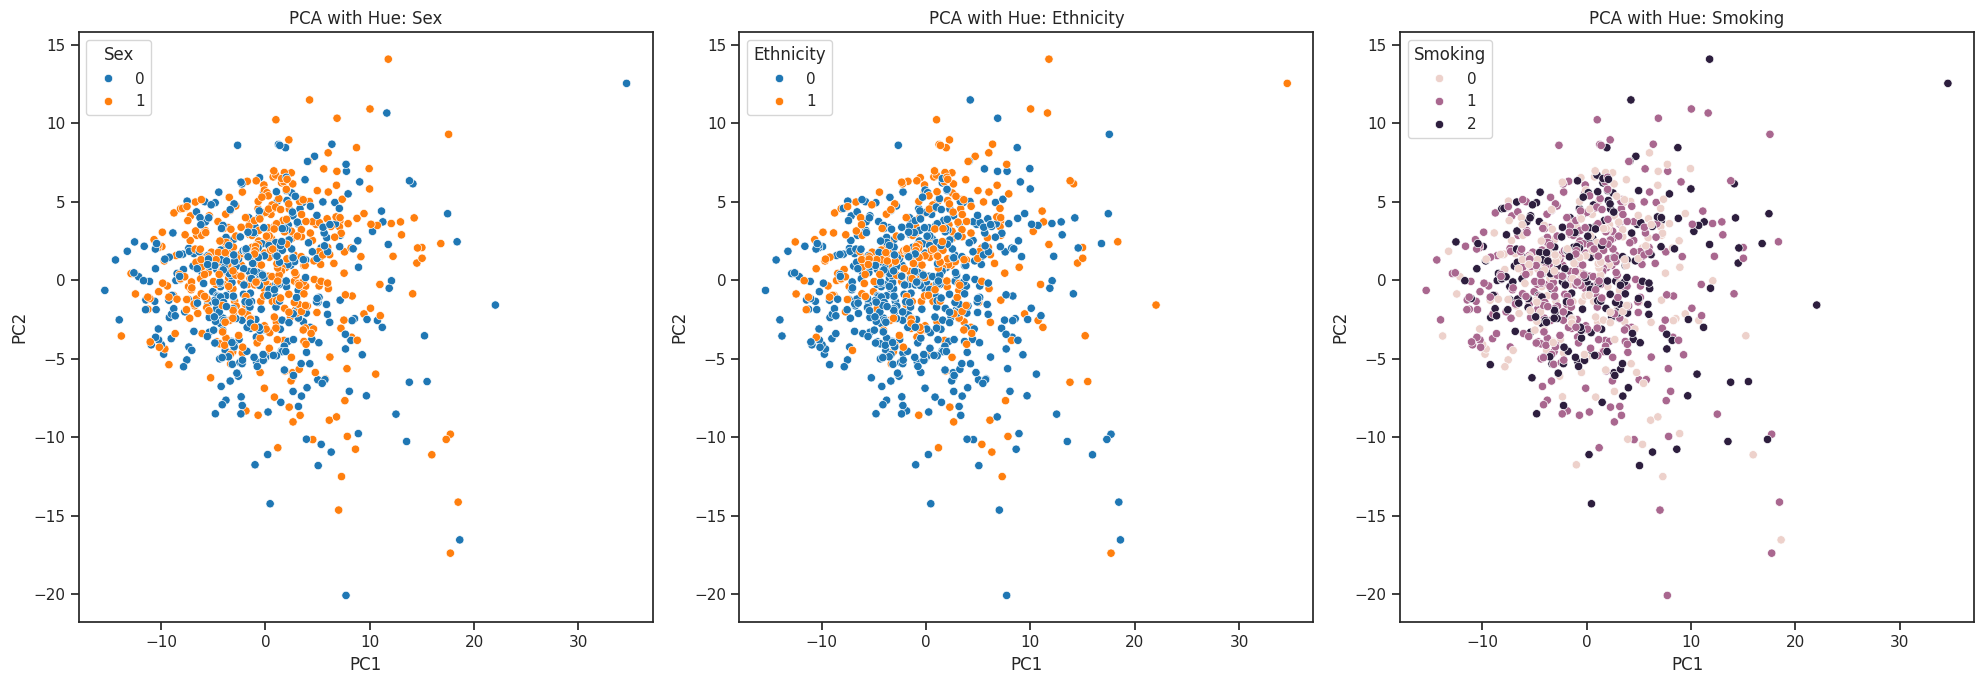

In [ ]:
# set plotting parameters
sns.set_style("ticks")
sns.set_context("notebook")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

hue_columns = ["Sex", "Ethnicity", "Smoking"]

for i, col in enumerate(hue_columns):
    sns.scatterplot(x=pca_df[:, 0], y=pca_df[:, 1], hue=df_unlabelled[col], ax=axes[i])
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2")
    axes[i].set_title(f"PCA with Hue: {col}")

plt.tight_layout()
plt.show()

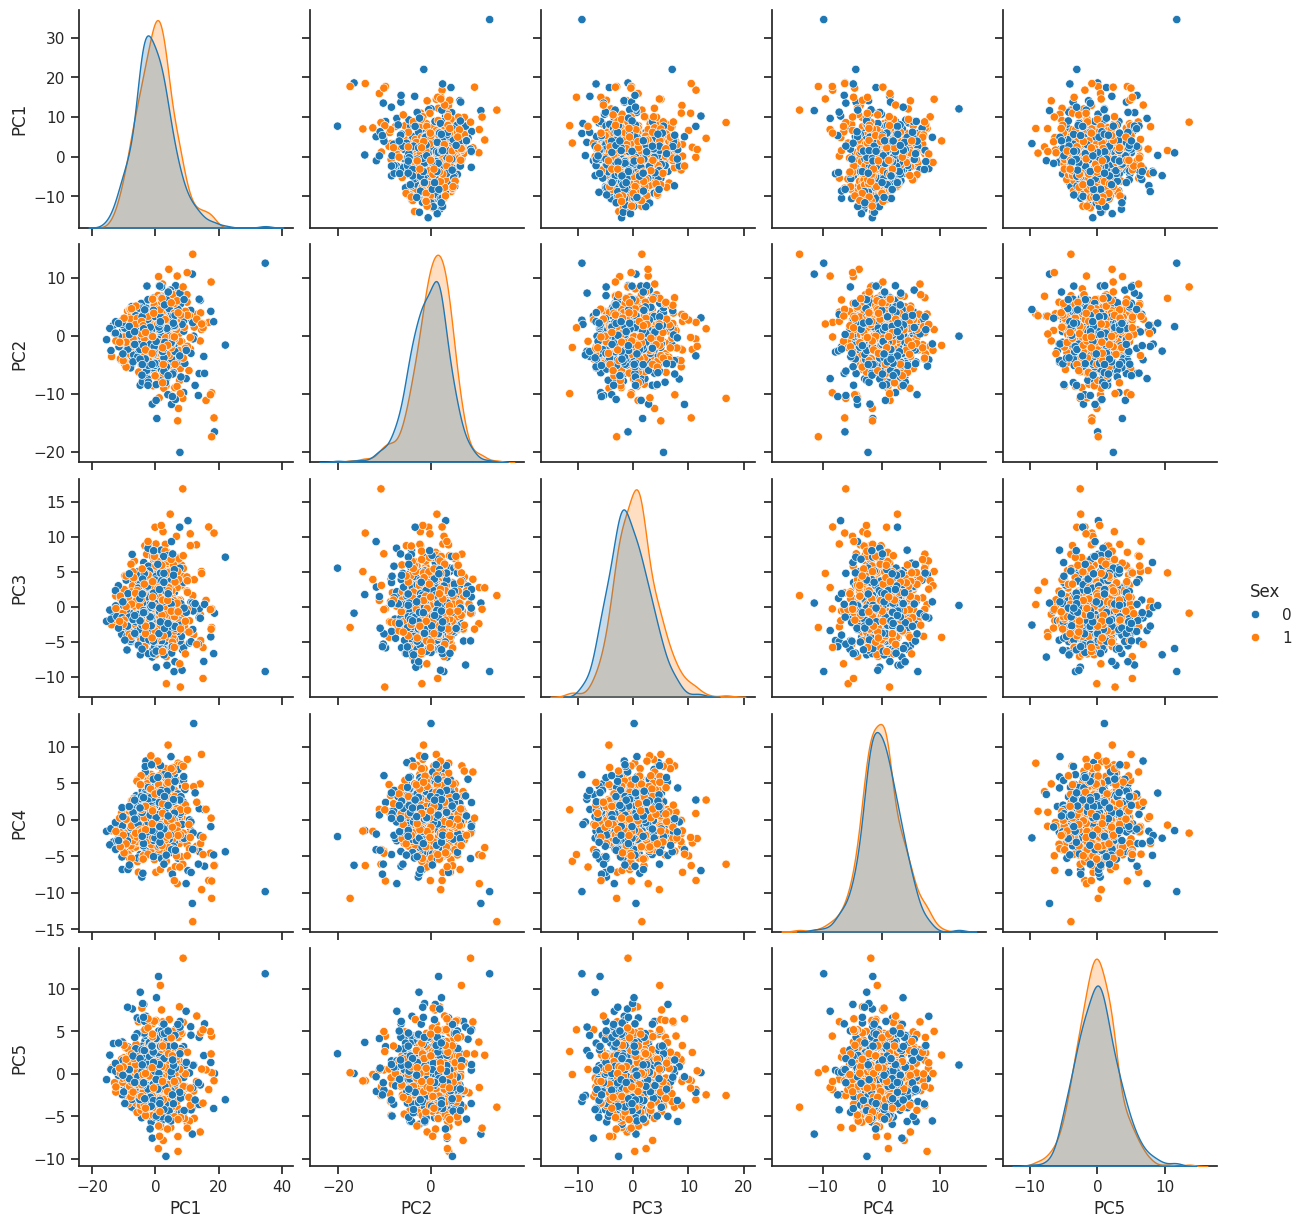

In [ ]:
pca_df = pd.DataFrame(pca_df, index=df_unlabelled.index)
pca_df.rename(columns={0:'PC1', 1:'PC2', 2:'PC3', 3:'PC4', 4:'PC5'}, inplace=True)
pca_df["Sex"] = df_unlabelled["Sex"]
pca_df["Ethnicity"] = df_unlabelled["Ethnicity"]
pca_df["Smoking"] = df_unlabelled["Smoking"]
p = sns.pairplot(pca_df, vars=['PC1', 'PC2', 'PC3', 'PC4','PC5'], hue="Sex")
plt.show()

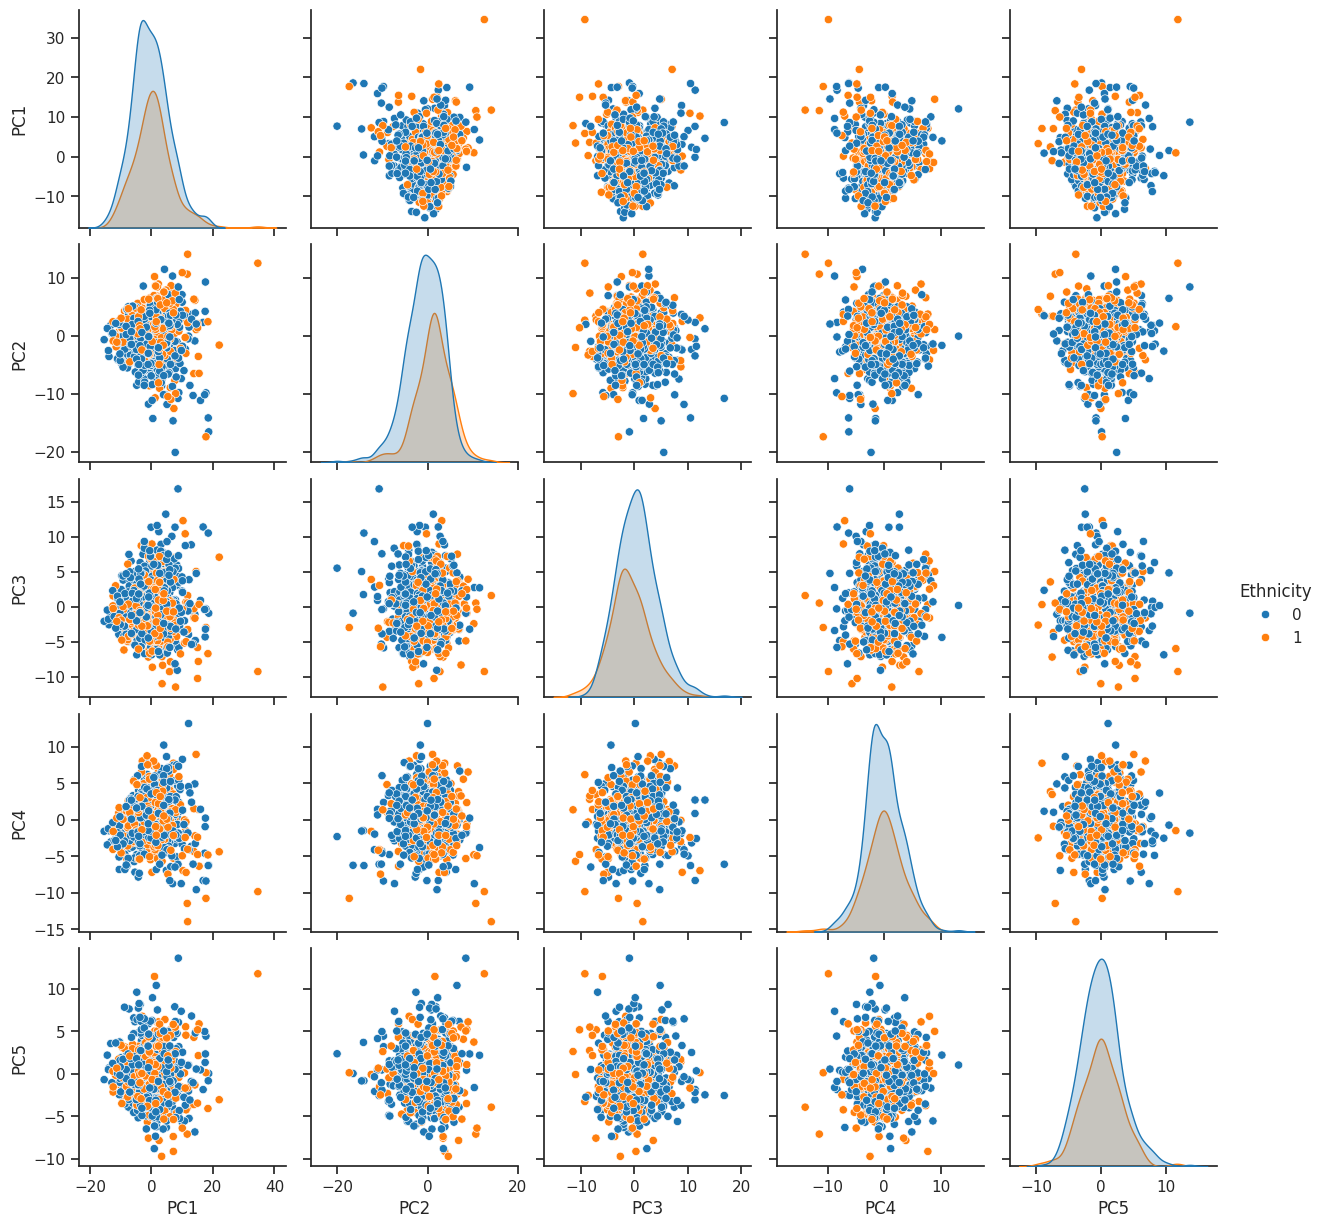

In [ ]:
p = sns.pairplot(pca_df, vars=['PC1', 'PC2', 'PC3', 'PC4','PC5'], hue="Ethnicity")
plt.show()

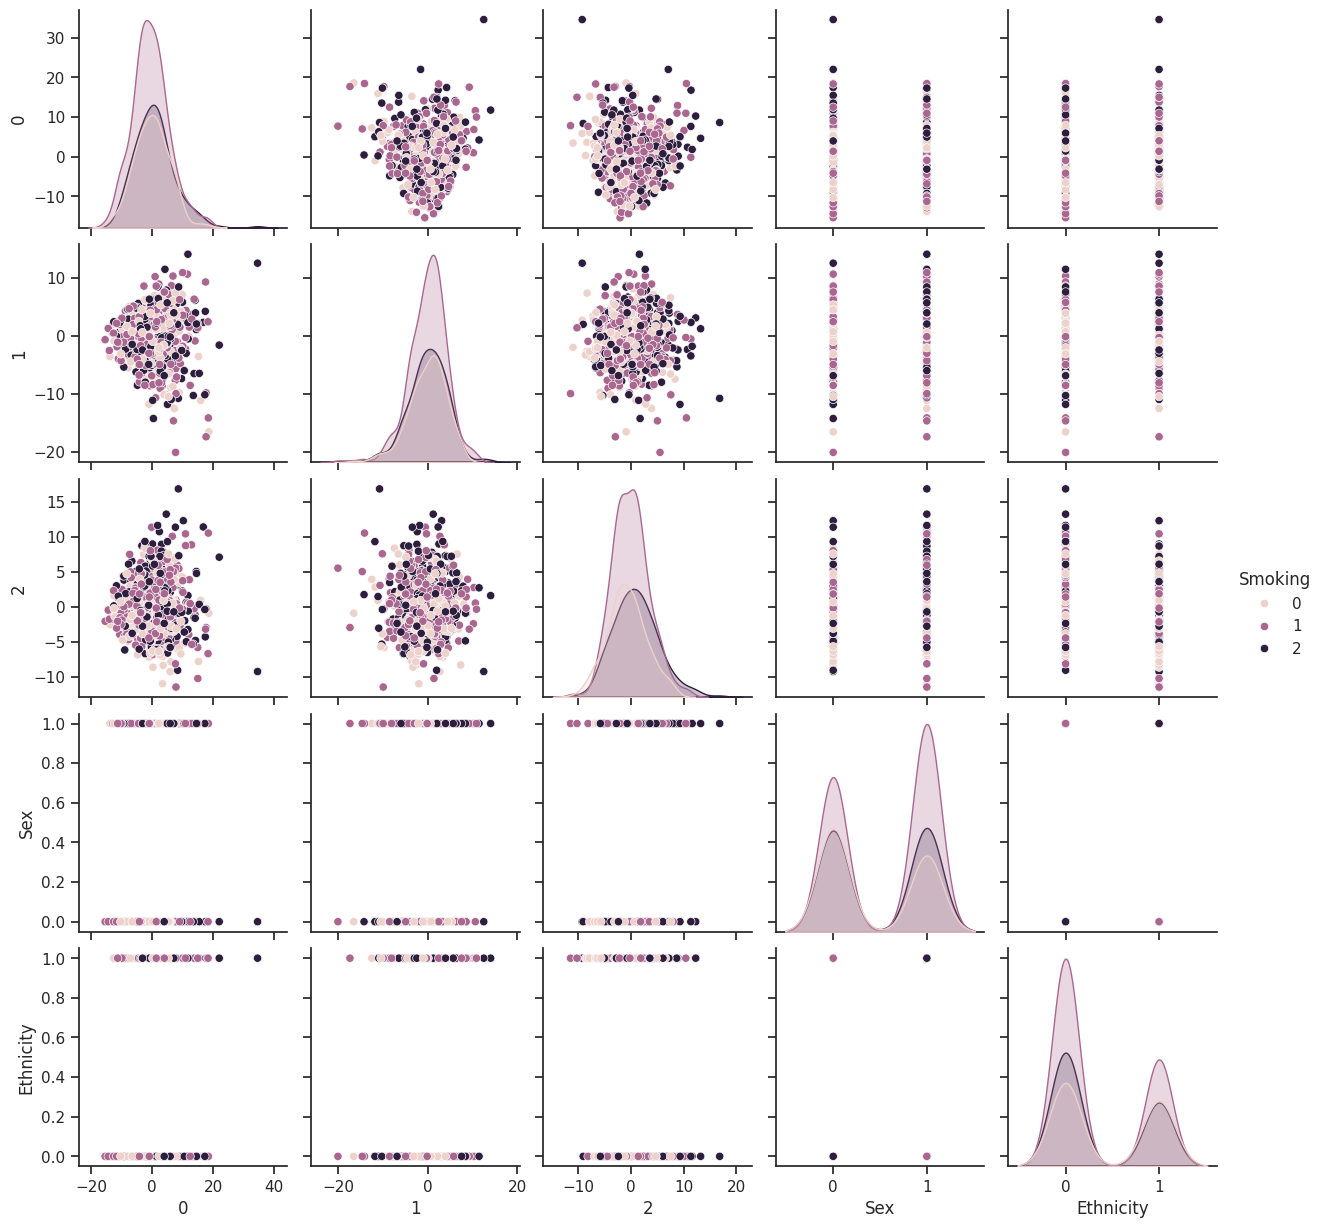

In [ ]:
p = sns.pairplot(pca_df, hue="Smoking")
plt.show()

### UMAP


In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import umap

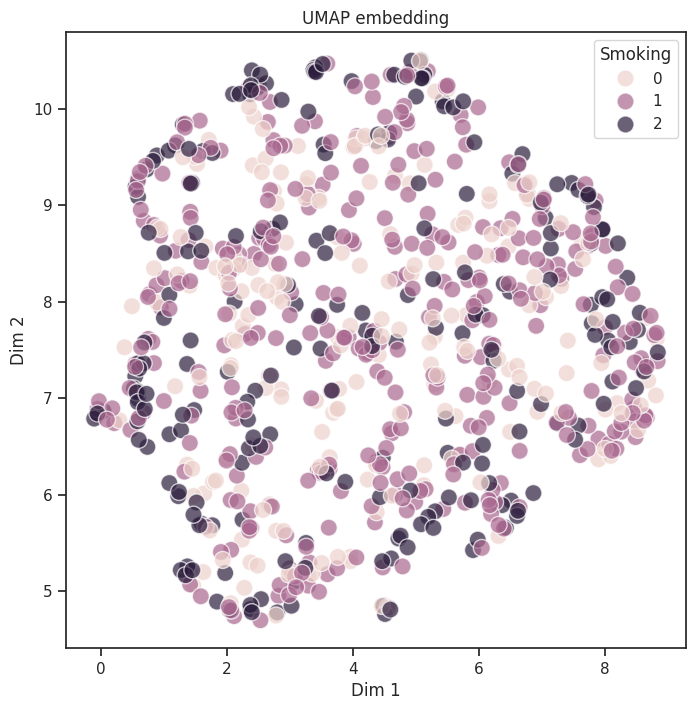

In [ ]:
#perform UMAP and project onto the scaled IBD data
UMAP_embedding = umap.UMAP().fit_transform(pca_df)
# plot UMAP embedding
plt.figure(figsize=(8, 8))
p = sns.scatterplot(x=UMAP_embedding[:, 0],
 y=UMAP_embedding[:, 1],
 hue=pca_df["Smoking"], # change this to colour points by other covariates
 s=150,
 alpha=0.7) # check what these parameters mean in the documentation, and change them to your liking

p.set_xlabel("Dim 1")
p.set_ylabel("Dim 2")
plt.title("UMAP embedding")

plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


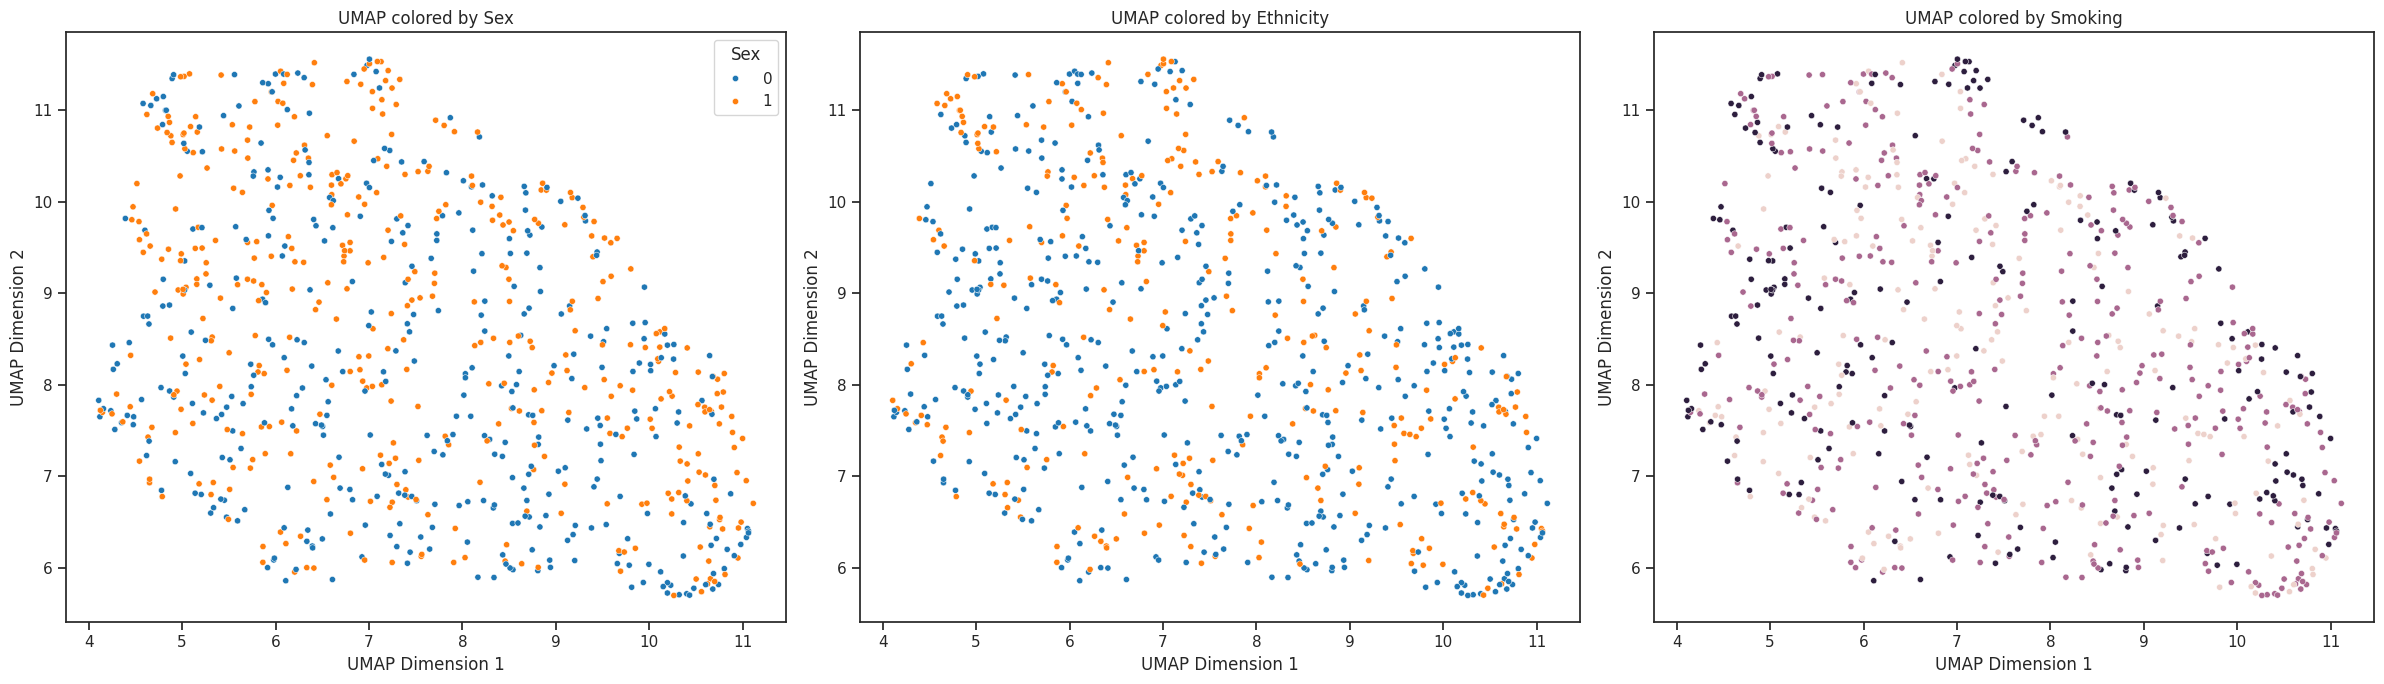

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7)) # Increased figsize for better readability

axs = [ax1, ax2, ax3]

# Define the columns to use for coloring
hue_columns = ["Sex", "Ethnicity", "Smoking"]

# Perform UMAP once on the PCA components from pca_df
# Adjust these parameters to try and reveal different clustering structures.
# - n_neighbors: Controls how UMAP balances local versus global structure.
#   Smaller values (e.g., 5-10) emphasize local structure, potentially revealing smaller clusters.
#   Larger values (e.g., 50-100+) emphasize global structure, which might show broader trends.
# - min_dist: Controls how tightly UMAP allows points to be packed together.
#   Smaller values (e.g., 0.0) result in denser clusters, while larger values (e.g., 0.5) spread points out more.
# - random_state: Set for reproducibility; keep this fixed while experimenting with other parameters.
umap_embedding = umap.UMAP(
    n_neighbors=15, # Default is 15. Try values like 5, 10, 20, 50.
    min_dist=0.1,    # Default is 0.1. Try values like 0.0, 0.05, 0.2, 0.5.
    random_state=42
).fit_transform(pca_df)

# Loop over each hue column to create a separate plot
for idx, hue_col in enumerate(hue_columns):
    # Plot the UMAP embedding, coloring by the current hue_col
    sns.scatterplot(
        x=umap_embedding[:, 0],
        y=umap_embedding[:, 1],
        hue=pca_df[hue_col], # Use pca_df[hue_col] for coloring
        ax=axs[idx],
        legend="full" if idx == 0 else False, # Only show legend for the first plot
        s=20 # Adjust point size for better visualization
    )

    axs[idx].set_title(f"UMAP colored by {hue_col}")
    axs[idx].set_xlabel("UMAP Dimension 1")
    axs[idx].set_ylabel("UMAP Dimension 2")

plt.tight_layout()
plt.show()

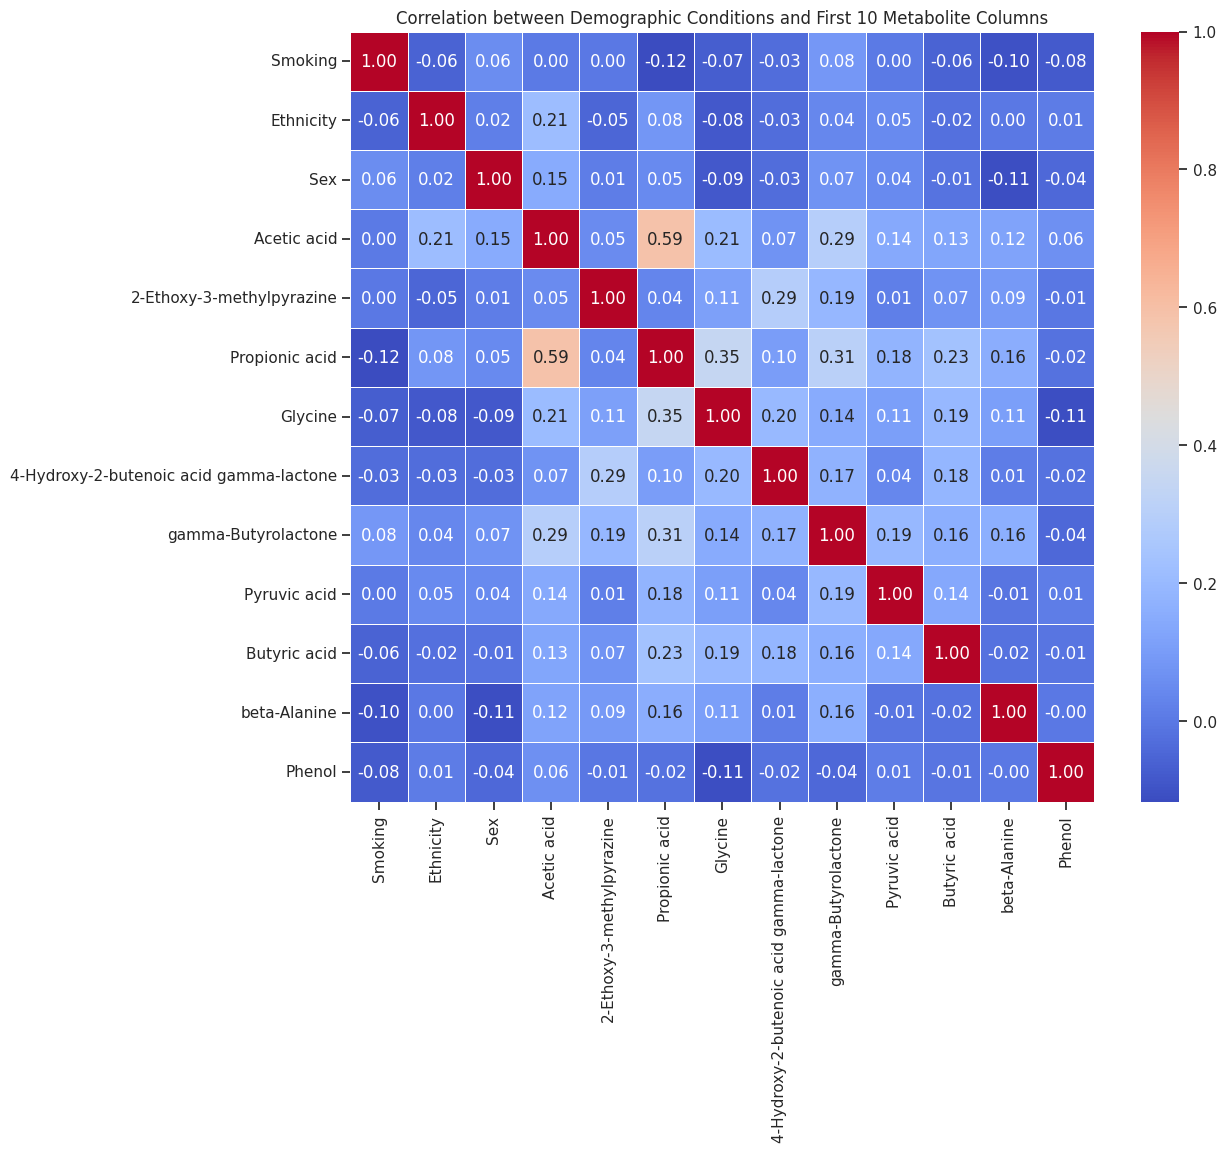

In [ ]:
# Extract 'Smoking', 'Ethnicity', 'Sex' columns and the first 10 metabolite columns
# Metabolite columns start from index 4 in df_unlabelled
metabolite_columns = df_unlabelled.iloc[:, 4:14]
demographic_columns = df_unlabelled[['Smoking', 'Ethnicity', 'Sex']]

# Combine them into a new DataFrame for correlation calculation
correlation_data = pd.concat([demographic_columns, metabolite_columns], axis=1)

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(12, 10)) # Adjusted figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation between Demographic Conditions and First 10 Metabolite Columns')
plt.show()

### DBSCAN

In [ ]:
NN = NearestNeighbors(n_neighbors=2)
nbrs = NN.fit(scaled_df.iloc[:, :-1])
distances, indices = nbrs.kneighbors(scaled_df.iloc[:, :-1])

distances = np.sort(distances, axis=0)
distances = distances[:,1]
# plt.plot(distances)
sns.lineplot(data=distances)
plt.axhline(y=19, color='r', linestyle='--')
plt.show()

In [ ]:
dbscan = DBSCAN(
    eps=19,
    min_samples=3,
    metric='euclidean'
).fit(scaled_df.iloc[:, :-1])

labels = dbscan.labels_
n_clusters_ = len(set(labels))
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print("Homogeneity: %0.3f" % metrics.homogeneity_score(scaled_df.iloc[:, -1], labels))
print("Completeness: %0.3f" % metrics.completeness_score(scaled_df.iloc[:, -1], labels))
print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(scaled_df.iloc[:, :-1], labels))

In [ ]:
sns.set_style("ticks")
sns.set_context("notebook")
plt.figure(figsize=(8, 8))

p = sns.scatterplot(x=pca_covid[:, 0], y=pca_covid[:, 1], hue=covid_proteomics["COVID19"])

p.set_xlabel("PC1")
p.set_ylabel("PC2")

plt.show()

In [ ]:
sns.set_style("ticks")
sns.set_context("notebook")
plt.figure(figsize=(8, 8))

p = sns.scatterplot(x=pca_df.iloc[:, 0], y=pca_df.iloc[:, 1], hue=covid_proteomics["COVID19"])

# proportions of variance explained by axes
pvars = pca_res.explained_variance_ratio_[:2] * 100

p.set_xlabel(("PC1: " "{:.2f}%".format(pvars[0])))
p.set_ylabel(("PC2: " "{:.2f}%".format(pvars[1])))

plt.show()